#### Correlation map

In [ ]:
import math
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from grid_determination_bizom.constant import ALL_COLS
from grid_determination_bizom.data_pipeline.data_aggregation import DataAggregator

In [2]:
FILE_PATH = "/Users/saranyapal/Developer/grid-determination-bizom/data/delhi_grids.csv"
df = pd.read_csv(FILE_PATH)
df.shape

(2000, 14)

In [3]:
transformer = DataAggregator(df)
full_df = transformer()

Extracting Image Features: 100%|██████████| 2000/2000 [00:02<00:00, 870.27it/s]


In [4]:
new_df = full_df[ALL_COLS]
new_df.columns

Index(['building_count', 'yellow_building_count', 'building_density',
       'yellow_building_density', 'total_building_density',
       'yellow_building_proportion', 'avg_yellow_building_size',
       'main_road_density', 'local_road_density', 'total_road_density',
       'water_percent', 'water_percent_log', 'waterbody', 'empty',
       'usable_area_percent', 'kirana_potential_index',
       'kirana_potential_index_log', 'local_road_proportion',
       'dist_to_nearest_hub', 'green_cover_ratio', 'edge_density',
       'structural_complexity', 'market_activity_index',
       'street_exposure_index'],
      dtype='object')

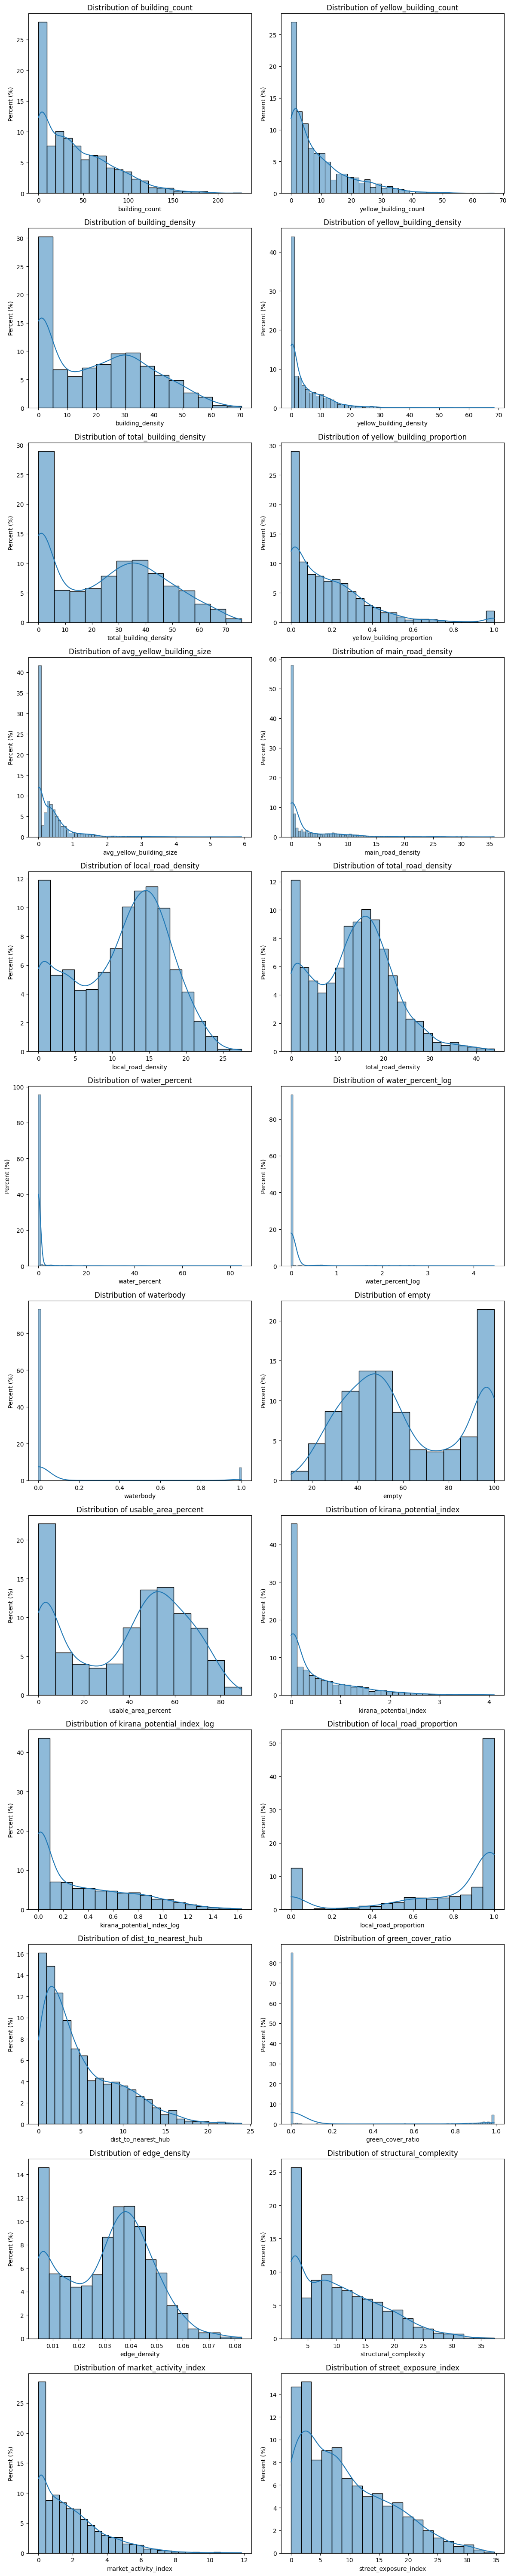

In [5]:
#   Distribution of Finalized features
num_cols = len(new_df.columns)
num_rows = math.ceil(num_cols / 2)

fig, axes = plt.subplots(num_rows, 2, figsize=(12, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(new_df.columns):
    sns.histplot(data=new_df, x=col, kde=True, ax=axes[i], stat="percent")

    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Percent (%)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
new_df.corr()

,building_count,yellow_building_count,building_density,yellow_building_density,total_building_density,yellow_building_proportion,avg_yellow_building_size,main_road_density,local_road_density,total_road_density,...,usable_area_percent,kirana_potential_index,kirana_potential_index_log,local_road_proportion,dist_to_nearest_hub,green_cover_ratio,edge_density,structural_complexity,market_activity_index,street_exposure_index
building_count,1.000000,0.432652,0.739247,0.151648,0.678316,-0.157181,0.026274,-0.133021,0.585129,0.363873,...,0.671217,0.097170,0.167201,0.461194,-0.258443,-0.392564,0.687450,0.906230,0.318805,0.897668
yellow_building_count,0.432652,1.000000,0.522322,0.677117,0.661333,0.426756,0.214848,0.072294,0.424756,0.353773,...,0.654078,0.668231,0.718473,0.273411,-0.362348,-0.334307,0.540793,0.561087,0.925430,0.524174
building_density,0.739247,0.522322,1.000000,0.315942,0.952970,-0.042068,0.194424,-0.116718,0.585346,0.372689,...,0.896323,0.169972,0.264977,0.495674,-0.398580,-0.445004,0.708496,0.792087,0.480074,0.794839
yellow_building_density,0.151648,0.677117,0.315942,1.000000,0.588624,0.367421,0.672606,0.159298,0.344514,0.340372,...,0.590757,0.890688,0.884236,0.174547,-0.336159,-0.274224,0.375122,0.267933,0.665920,0.229644
total_building_density,0.678316,0.661333,0.952970,0.588624,1.000000,0.081519,0.380506,-0.048566,0.608791,0.426273,...,0.952415,0.429333,0.508221,0.478094,-0.446988,-0.466760,0.723498,0.760482,0.621759,0.750597
yellow_building_proportion,-0.157181,0.426756,-0.042068,0.367421,0.081519,1.000000,0.217708,0.241163,0.122354,0.218864,...,0.139678,0.438248,0.429117,0.097649,-0.050245,-0.297021,0.119075,-0.053746,0.579540,-0.062681
avg_yellow_building_size,0.026274,0.214848,0.194424,0.672606,0.380506,0.217708,1.000000,0.220321,0.339571,0.369093,...,0.432113,0.621512,0.647210,0.129837,-0.209519,-0.255298,0.284677,0.099088,0.285149,0.070932
main_road_density,-0.133021,0.072294,-0.116718,0.159298,-0.048566,0.241163,0.220321,1.000000,0.211695,0.688000,...,0.192543,0.289045,0.294409,-0.291510,-0.080222,-0.150880,0.167433,-0.081431,0.130501,-0.228035
local_road_density,0.585129,0.424756,0.585346,0.344514,0.608791,0.122354,0.339571,0.211695,1.000000,0.854909,...,0.780442,0.376588,0.446476,0.549081,-0.300531,-0.520756,0.901721,0.668934,0.456324,0.651912
total_road_density,0.363873,0.353773,0.372689,0.340372,0.426273,0.218864,0.369093,0.688000,0.854909,1.000000,...,0.681713,0.433059,0.487801,0.252980,-0.265739,-0.466770,0.758439,0.453486,0.408110,0.363028


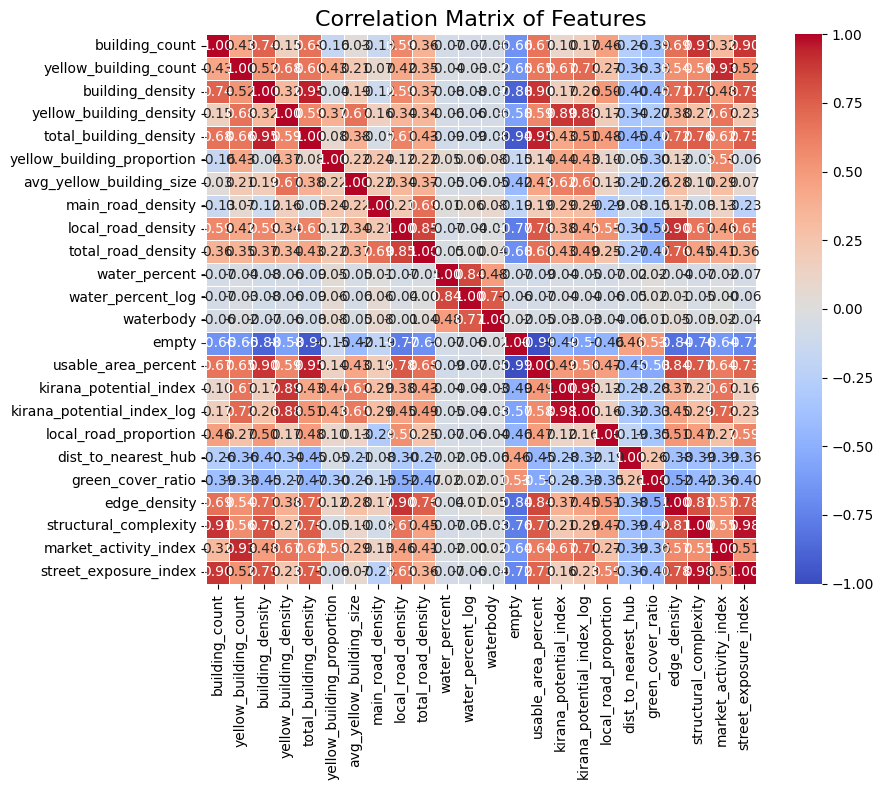

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    new_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Matrix of Features", fontsize=16)
plt.tight_layout()